In [12]:
from pyscf import gto, scf
import numpy as np
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.external import RHF_context_from_pyscf

In [13]:

large_basis = '''
He    S
      5.285000E+02           0.000000E+00           9.400000E-04           0.000000E+00           0.000000E+00
      7.931000E+01           0.000000E+00           7.214000E-03           0.000000E+00           0.000000E+00
      1.805000E+01           0.000000E+00           3.597500E-02           0.000000E+00           0.000000E+00
      5.085000E+00           0.000000E+00           1.277820E-01           0.000000E+00           0.000000E+00
      1.609000E+00           1.000000E+00           3.084700E-01           0.000000E+00           0.000000E+00
      5.363000E-01           0.000000E+00           4.530520E-01           1.000000E+00           0.000000E+00
      1.833000E-01           0.000000E+00           2.388840E-01           0.000000E+00           1.000000E+00
He    S
      0.0481900              1.0000000
He    P
      5.994000E+00           1.000000E+00           0.000000E+00           0.000000E+00
      1.745000E+00           0.000000E+00           1.000000E+00           0.000000E+00
      5.600000E-01           0.000000E+00           0.000000E+00           1.000000E+00
He    P
      0.1626000              1.0000000
He    D
      4.299000E+00           1.000000E+00           0.000000E+00
      1.223000E+00           0.000000E+00           1.000000E+00
He    D
      0.3510000              1.0000000
He    F
      2.680000E+00           1.0000000
He    F
      0.6906000              1.0000000
END
'''

converged SCF energy = -2.86152199563245


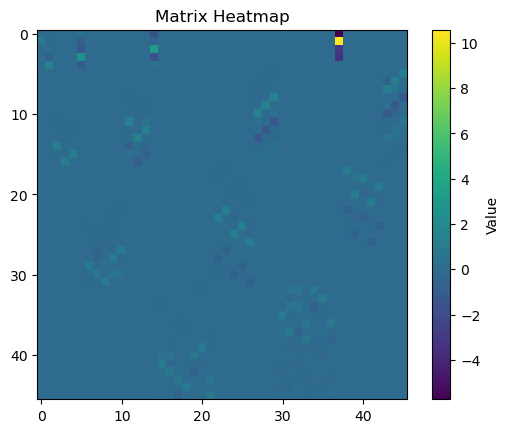

[ 1.00118477  0.63946381  0.86684257  0.90767732  1.127644    0.01377989
  0.82998201 -0.18337076  1.05529029  1.21346847  1.09436329  0.37558452
  0.53944122  0.61841213 -0.12656163  1.51922332  0.79262726  0.29470575
  0.91330413 -0.04349804  1.00271241  1.20554563  0.67665597  0.61068685
  0.47679826  0.64158394  0.54202914  0.51923741  0.58289176  0.71449678
  0.97374561  0.91271624  0.6859648   1.03031293  0.04073571  0.68883991
  0.16234275 -1.27673947  0.74666104  0.93419328  0.49368194  0.78713509
  0.70454202  0.35248064  0.74406566  0.63608828]


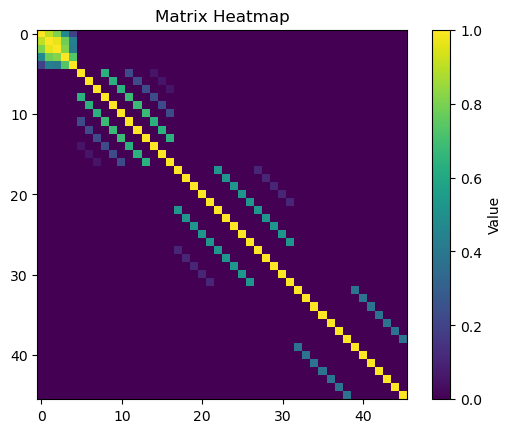

In [14]:
# pyscf data
pyscf_args = {
    'atom': 'He 0 0 0',
    'spin': 0,
    'charge': 0,
    'basis': 'aug-cc-pvqz',
}

mol = gto.M(**pyscf_args)
mol.basis = {'He': gto.basis.parse(large_basis)}
mol.build()

mf = scf.RHF(mol) 
e_He = mf.kernel()
e_elec = mf.energy_elec()

plot_map(mf.mo_coeff)
sum_cols = np.sum(mf.mo_coeff, axis=0)
print(sum_cols)
plot_map(mol.intor('int1e_ovlp'))
# mymp = mp.RMP2(mf).run() # this is UMP2

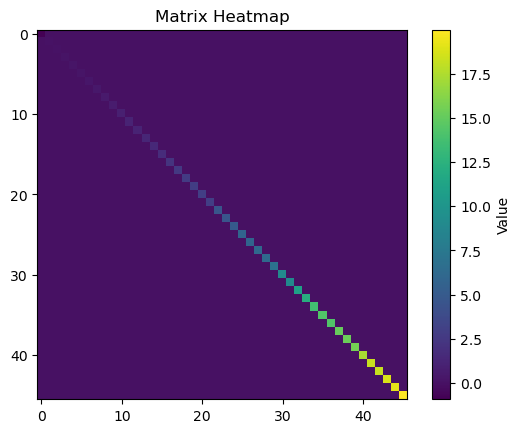

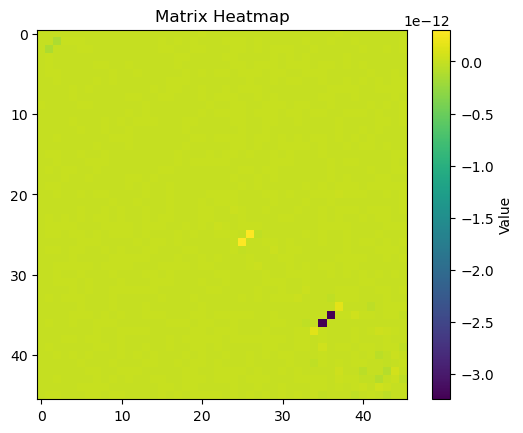

In [18]:
# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_cxt.theta = 0.00
RHF_cxt.occupation = np.array([2,0])
RHF_cxt.threshold = 1E-14
RHF_res = CS_RHF(RHF_cxt)

C_munu = RHF_res.R_munu.real
F_MO = RHF_res.R_munu.real.T @ RHF_res.F_final.real @ RHF_res.R_munu.real
plot_map(F_MO)
plot_map(F_MO-np.diag(np.diagonal(F_MO)))

In [19]:
print(RHF_res.e_orb.real-mf.mo_energy)

[-3.41843672e-08  1.03261283e-09  2.63326566e-09  2.63326466e-09
  2.63326277e-09  1.89275384e-09  1.41035250e-09  1.41035317e-09
  1.41035694e-09  1.41035672e-09  1.41035339e-09 -2.24750116e-08
 -2.24750150e-08 -2.24750094e-08 -3.39874227e-08 -1.63972169e-09
 -1.63972347e-09 -1.63972169e-09 -1.63972036e-09 -1.63971237e-09
 -1.63971414e-09 -1.63971192e-09 -2.76495609e-08 -2.76495626e-08
 -2.76495555e-08 -2.76495458e-08 -2.76495555e-08 -4.51985205e-08
 -4.51985205e-08 -4.51985045e-08 -5.44351906e-08 -5.44351977e-08
 -5.44351799e-08 -5.44351799e-08 -5.44351746e-08 -5.44351675e-08
 -5.44351568e-08 -1.00903847e-07 -8.59462226e-08 -8.59462226e-08
 -8.59462013e-08 -8.59461586e-08 -8.59461373e-08 -1.03395006e-07
 -1.03394953e-07 -1.03394960e-07]


Which is not large, but however these energy differences might be enough to break the MP2. 

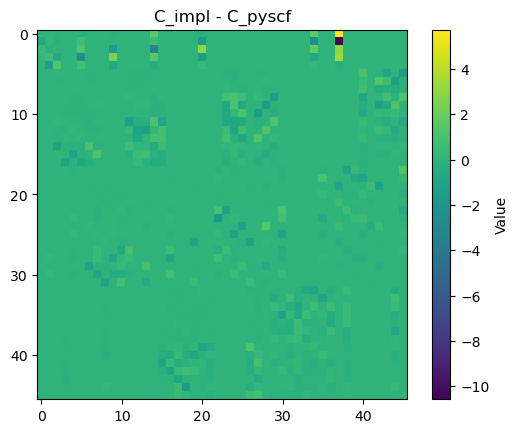

In [20]:
plot_map(C_munu - mf.mo_coeff, title='C_impl - C_pyscf')